## Bucket Catalog Visualisation

This notebook summarizes the live bucket catalog without relying on legacy PT repositories.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
from maya4 import DEFAULT_BUCKET_ID, list_base_files_in_bucket, parse_product_filename

rows = []
for file_name in sorted(list_base_files_in_bucket(DEFAULT_BUCKET_ID, relative_path=True)):
    if not file_name.endswith('.zarr'):
        continue
    meta = parse_product_filename(file_name)
    rows.append(
        {
            'filename': file_name,
            'acquisition_date': meta['acquisition_date'],
            'satellite': meta['satellite'].upper(),
            'stripmap_mode': meta['stripmap_mode'],
            'polarization': meta['polarization'].upper(),
        }
    )

catalog = pd.DataFrame(rows).sort_values('acquisition_date').reset_index(drop=True)
print(catalog[['filename', 'acquisition_date', 'stripmap_mode', 'polarization']].head(8).to_string(index=False))
print('\nproducts per polarization:')
print(catalog['polarization'].value_counts().to_string())


                                                          filename    acquisition_date  stripmap_mode polarization
s1c-s1-raw-s-vv-20250328t052810-20250328t052835-001637-002a0d.zarr 2025-03-28 05:28:10              1           VV
s1c-s4-raw-s-vv-20250328t145502-20250328t145535-001643-002a6d.zarr 2025-03-28 14:55:02              4           VV
s1c-s4-raw-s-vv-20250328t145527-20250328t145555-001643-002a6d.zarr 2025-03-28 14:55:27              4           VV
s1c-s4-raw-s-vv-20250329t061359-20250329t061431-001652-002b01.zarr 2025-03-29 06:13:59              4           VV
s1c-s4-raw-s-vv-20250329t061424-20250329t061459-001652-002b01.zarr 2025-03-29 06:14:24              4           VV
s1c-s4-raw-s-vv-20250330t051150-20250330t051214-001666-002bd3.zarr 2025-03-30 05:11:50              4           VV
s1c-s2-raw-s-vv-20250331t205042-20250331t205107-001690-002d5c.zarr 2025-03-31 20:50:42              2           VV
s1c-s6-raw-s-vv-20250401t161424-20250401t161448-001702-002e19.zarr 2025-04-01 16

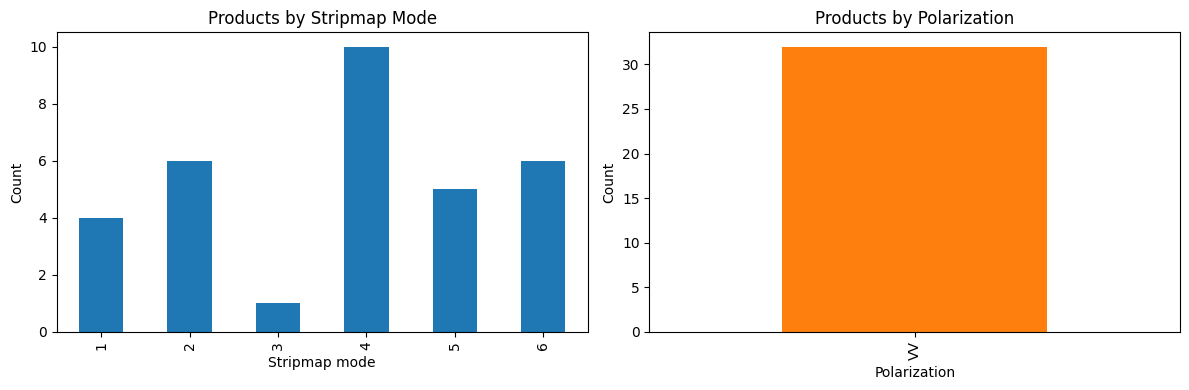

In [2]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from maya4 import DEFAULT_BUCKET_ID, list_base_files_in_bucket, parse_product_filename

rows = []
for file_name in sorted(list_base_files_in_bucket(DEFAULT_BUCKET_ID, relative_path=True)):
    if not file_name.endswith('.zarr'):
        continue
    meta = parse_product_filename(file_name)
    rows.append(
        {
            'acquisition_date': meta['acquisition_date'],
            'stripmap_mode': meta['stripmap_mode'],
            'polarization': meta['polarization'].upper(),
        }
    )

catalog = pd.DataFrame(rows).sort_values('acquisition_date').reset_index(drop=True)
mode_counts = catalog['stripmap_mode'].value_counts().sort_index()
pol_counts = catalog['polarization'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mode_counts.plot(kind='bar', ax=axes[0], color='#1f77b4', title='Products by Stripmap Mode')
axes[0].set_xlabel('Stripmap mode')
axes[0].set_ylabel('Count')

pol_counts.plot(kind='bar', ax=axes[1], color='#ff7f0e', title='Products by Polarization')
axes[1].set_xlabel('Polarization')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()
